In [ ]:
from zipfile import ZipFile

# Path to the ZIP file
zip_file_path = '/content/ad.zip'

# Extract to a specified directory
output_dir = '/content/dataset'

with ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(output_dir)

print(f'Folder extracted to {output_dir}')


Folder extracted to /content/dataset


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Reshape, Dropout
from tensorflow.keras.models import Sequential
import matplotlib.pyplot as plt
from tensorflow.keras.layers import ReLU
import os,cv2
import json
import glob
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import SGD, RMSprop, Adam
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers
from tensorflow import keras
import h5py
import matplotlib.image as img
%matplotlib inline

In [ ]:
!pip install split-folders
import splitfolders

# Replace with the path where your dataset is located (e.g., uploaded or Google Drive)
input_folder = '/content/dataset/ad'  # Update this path
output_folder = '/content/output'

# Split dataset into training, validation, and test sets
splitfolders.ratio(input_folder, output=output_folder, seed=1345, ratio=(.8, 0.1, 0.1))

print("Dataset has been split successfully!")


Copying files: 6400 files [00:01, 5175.76 files/s]

Dataset has been split successfully!


In [ ]:
IMG_HEIGHT = 128
IMG_WIDTH = 128
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
'/content/output/train',
seed=123,
image_size=(IMG_HEIGHT, IMG_WIDTH),
batch_size=16
)

Found 5119 files belonging to 4 classes.


In [ ]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
'/content/output/test',
seed=123,
image_size=(IMG_HEIGHT, IMG_WIDTH),
batch_size=32
)

Found 642 files belonging to 4 classes.


In [ ]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
'/content/output/val',
seed=123,
image_size=(IMG_HEIGHT, IMG_WIDTH),
batch_size=32
)

Found 639 files belonging to 4 classes.


In [ ]:
class_names = train_ds.class_names
print(class_names)
train_ds

['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

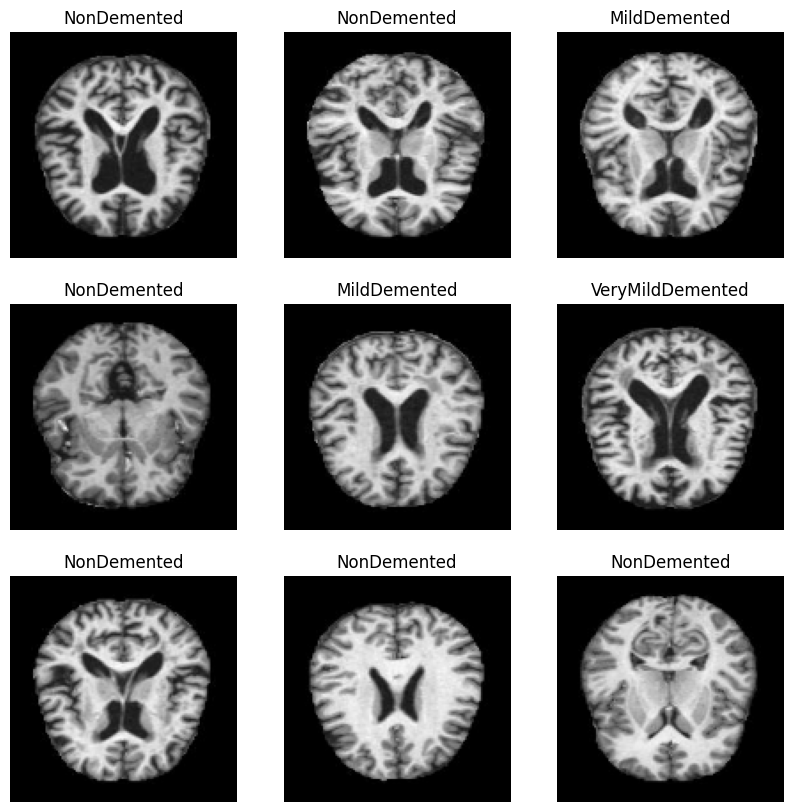

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

<function matplotlib.pyplot.show(close=None, block=None)>

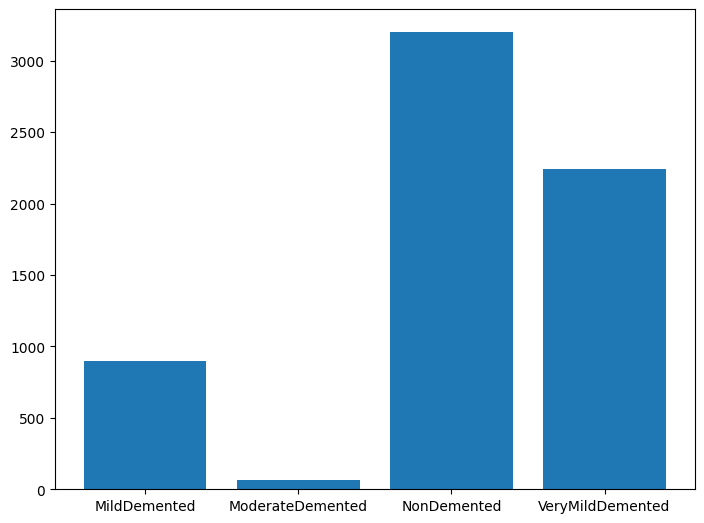

In [ ]:
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
size = [896,64,3200,2240]
ax.bar(class_names,size)
plt.show

In [ ]:
model = Sequential([
    keras.layers.Convolution2D(256, 3, activation='relu', padding='same', input_shape=(128,128,3), kernel_initializer="he_normal", strides=1),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Convolution2D(256, 3, activation='relu', padding='same', kernel_initializer="he_normal", strides=1),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Convolution2D(128, 3, activation='relu', padding='same', kernel_initializer="he_normal", strides=1),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Dropout(0.2),
    keras.layers.Convolution2D(64, 3, activation='relu', padding='same', kernel_initializer="he_normal", strides=1),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Convolution2D(32, 3, activation='relu', padding='same', kernel_initializer="he_normal", strides=1),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Dropout(0.2),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu', kernel_initializer="he_normal"),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(4, activation='softmax')
    ])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 256)       │           7,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 128)         │         295,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 8, 8, 32)            │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 4, 4, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 4, 4, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,058,724 (4.04 MB)

 Trainable params: 1,058,724 (4.04 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss="sparse_categorical_crossentropy", optimizer = "Adam",metrics=["accuracy"])

In [ ]:
hist = model.fit(train_ds,validation_data=val_ds,epochs=200, batch_size=16, verbose=1)

Epoch 1/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 49s 112ms/step - accuracy: 0.4066 - loss: 52.5336 - val_accuracy: 0.4601 - val_loss: 1.0419
Epoch 2/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 52s 55ms/step - accuracy: 0.4567 - loss: 1.0943 - val_accuracy: 0.4977 - val_loss: 1.0143
Epoch 3/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.4903 - loss: 1.0509 - val_accuracy: 0.5164 - val_loss: 1.0224
Epoch 4/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 22s 60ms/step - accuracy: 0.4964 - loss: 1.0354 - val_accuracy: 0.5274 - val_loss: 0.9938
Epoch 5/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.5085 - loss: 1.0237 - val_accuracy: 0.5070 - val_loss: 1.0097
Epoch 6/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - accuracy: 0.4775 - loss: 1.0472 - val_accuracy: 0.5430 - val_loss: 0.9881
Epoch 7/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - accuracy: 0.5146 - loss: 1.0085 - val_accuracy: 0.5446 - val_loss: 0.9837
Epoch 8/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - accuracy: 0.5334 - loss:

In [ ]:
model.save('model.h5')
print('Model saved!!')

Model saved!!


In [ ]:
accuracy = hist.history['accuracy']
loss = hist.history['loss']
val_acc = hist.history['val_accuracy']
val_loss = hist.history['val_loss']

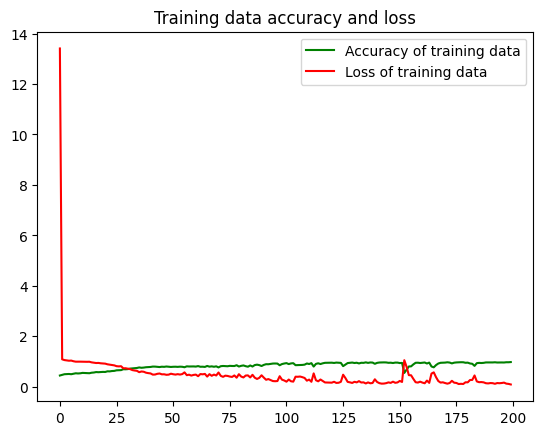

<Figure size 640x480 with 0 Axes>

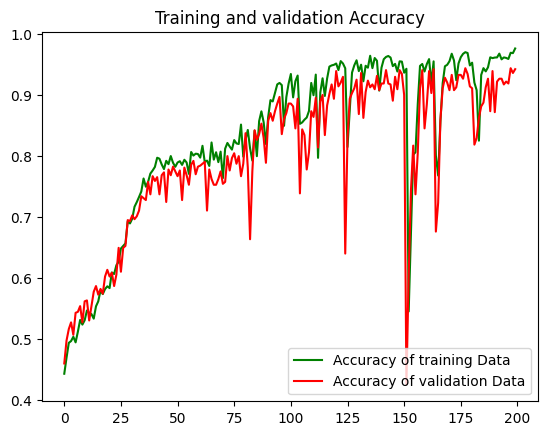

<Figure size 640x480 with 0 Axes>

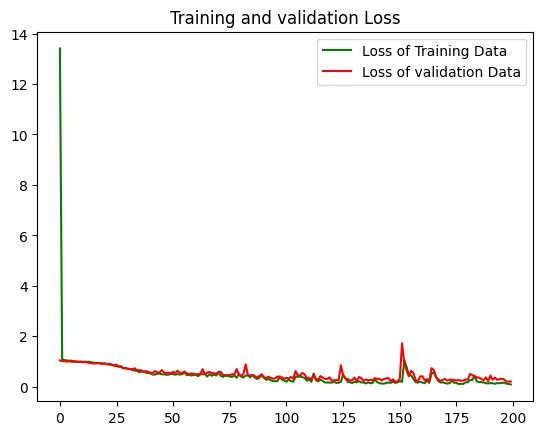

<Figure size 640x480 with 0 Axes>

In [ ]:
epochs = range(len(accuracy))
plt.plot(epochs, accuracy, 'g', label='Accuracy of training data')
plt.plot(epochs, loss, 'r', label='Loss of training data')
plt.title('Training data accuracy and loss')
plt.legend(loc=0)
plt.figure()
plt.show()


plt.plot(epochs, accuracy, 'g', label='Accuracy of training Data')
plt.plot(epochs, val_acc, 'r', label='Accuracy of validation Data')
plt.title('Training and validation Accuracy')
plt.legend(loc=0)
plt.figure()
plt.show()


plt.plot(epochs, loss, 'g', label='Loss of Training Data')
plt.plot(epochs, val_loss, 'r', label='Loss of validation Data')
plt.title('Training and validation Loss')
plt.legend(loc=0)
plt.figure()
plt.show()

In [ ]:
loss, accuracy = model.evaluate(test_ds)

21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 139ms/step - accuracy: 0.9369 - loss: 0.2460


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


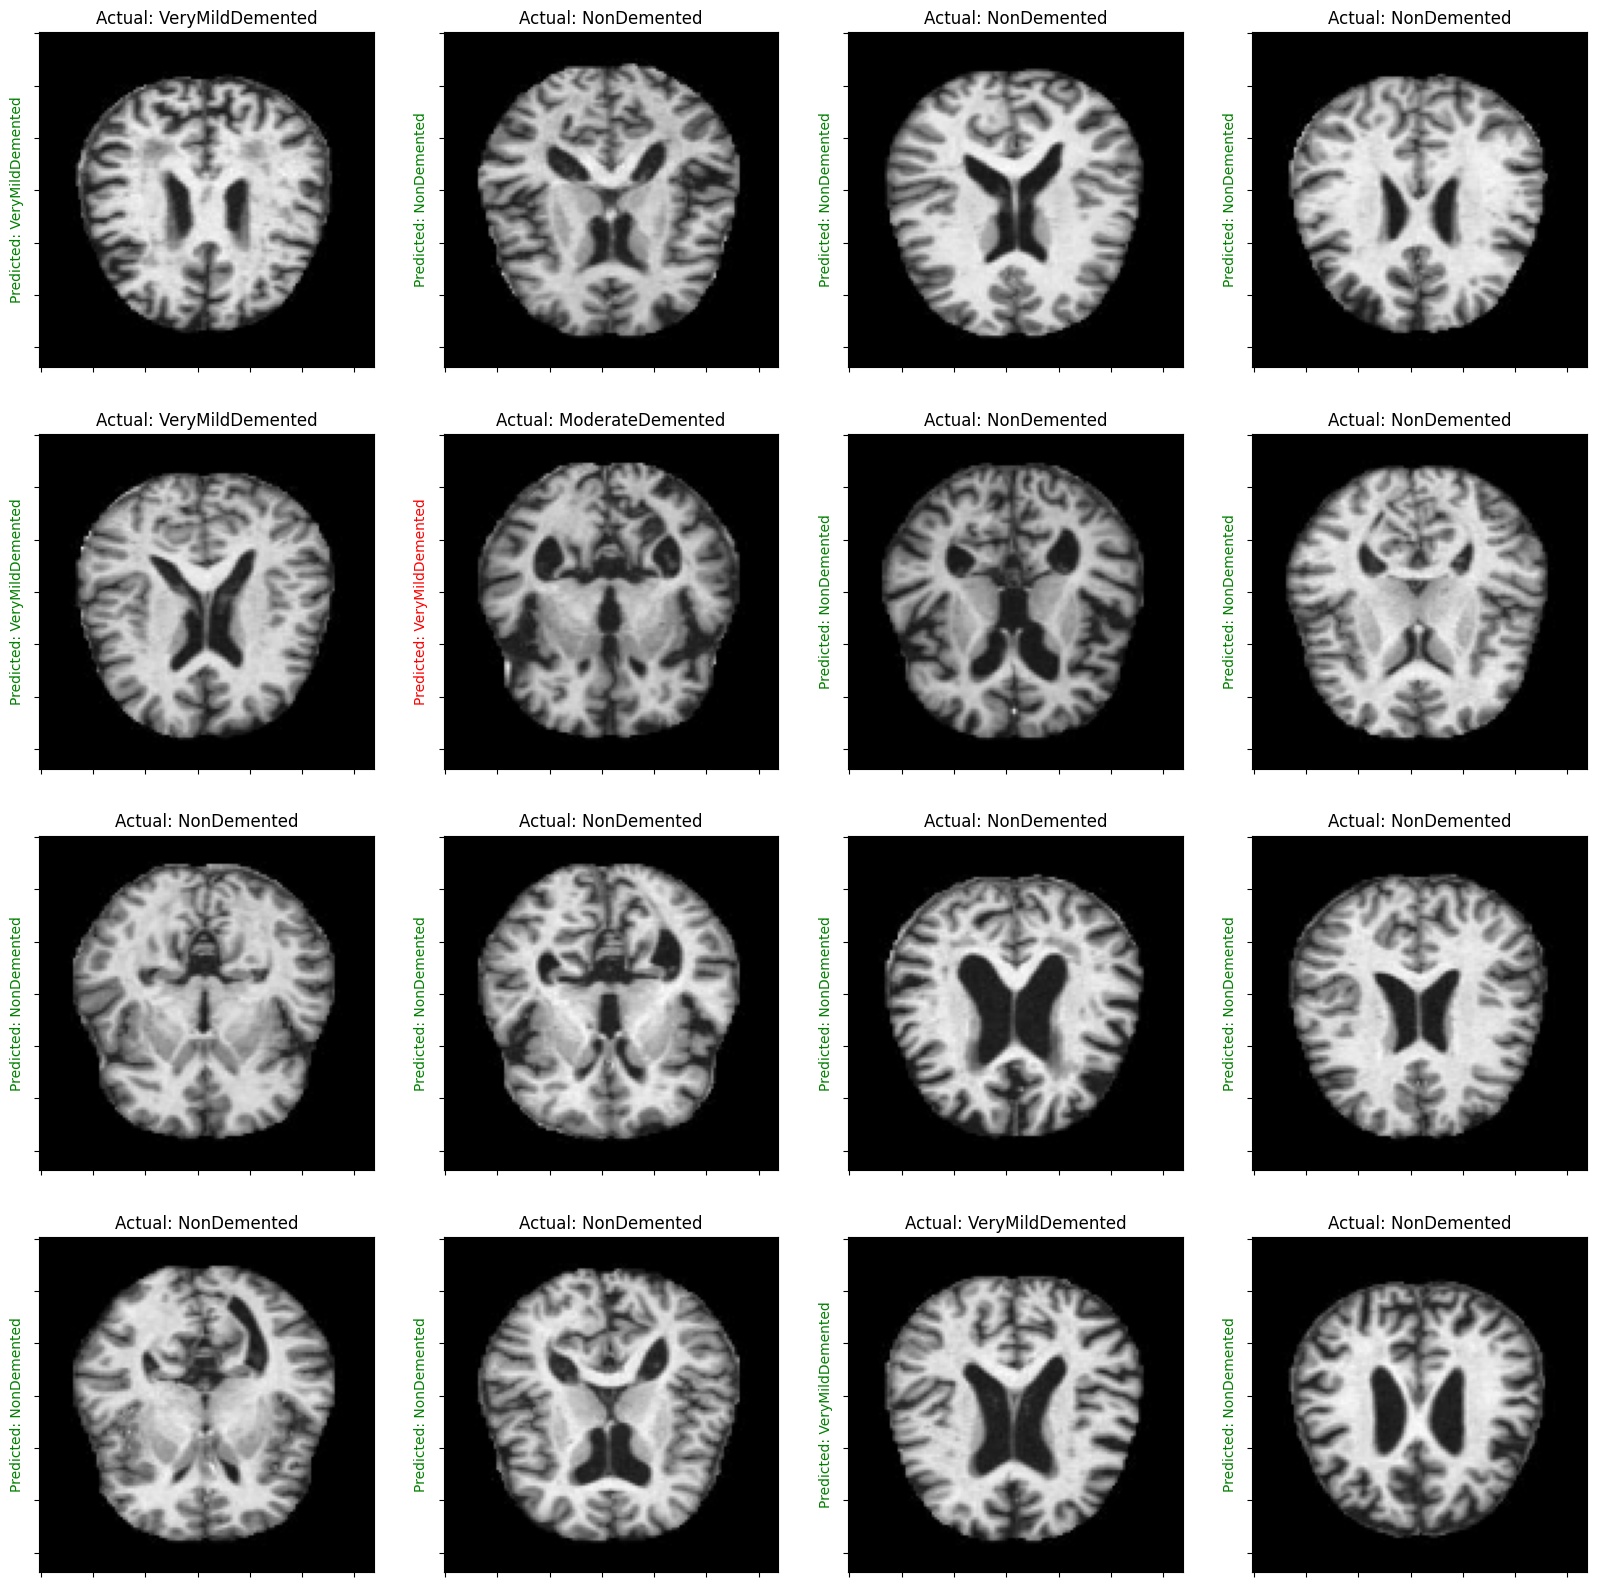

In [ ]:
plt.figure(figsize=(20, 20))
for images, labels in test_ds.take(1):
    for i in range(16):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        predictions = model.predict(tf.expand_dims(images[i], 0))
        score = tf.nn.softmax(predictions[0])
        if(class_names[labels[i]]==class_names[np.argmax(score)]):
            plt.title("Actual: "+class_names[labels[i]])
            plt.ylabel("Predicted: "+class_names[np.argmax(score)],fontdict={'color':'green'})

        else:
            plt.title("Actual: "+class_names[labels[i]])
            plt.ylabel("Predicted: "+class_names[np.argmax(score)],fontdict={'color':'red'})
        plt.gca().axes.yaxis.set_ticklabels([])
        plt.gca().axes.xaxis.set_ticklabels([])